# ζ-Normalization Calculator & Analyzer

**Comprehensive toolkit for computing and visualizing κζ (kappa zeta) curvature**

This notebook provides:
1. **ZetaTranslator Calculator** - Compute κζ on arbitrary matrices
2. **ZetaBlock Runtime Analysis** - Live κζ from model activations  
3. **Component Visualization** - τ/σ pathway analysis
4. **Parameter Monitoring** - β/t adaptation tracking
5. **Multi-layer Profiling** - Curvature across depth
6. **Training History** - Visualize checkpoint metrics

---

**Noetic Eidos Project**  
*Two timescales, one control target: the critical line awaits.*

## Section 1: Setup & Model Loading

Load a trained ζ-normalized model from checkpoint and inspect its state.

In [1]:
# Imports
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import seaborn as sns

# ZetaFormer modules
from training_loop_enhanced import load_zeta_model
from zeta_translator import ZetaTranslator
from zeta_block_enhanced import ZetaBlockEnhanced
import notebook_helpers as nh

# Configure plotting
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

print("✓ Imports successful")

✓ Imports successful


In [2]:
# Load trained model from checkpoint
CHECKPOINT_PATH = './zeta_comparison_results/zeta_normalized/model_checkpoint.pt'

model, classifier, metrics_dict, hparams = load_zeta_model(
    CHECKPOINT_PATH,
    device='cpu'  # Change to 'cuda' if GPU available
)

# Extract ZetaTranslator
translator = model.zeta_translator

print("\n" + "="*70)
print("Model Configuration:")
print("="*70)
print(f"d_model: {model.d_model}")
print(f"n_heads: {model.n_heads}")
print(f"ζ-normalization: {'Enabled' if model.enable_zeta_norm else 'Disabled'}")
print(f"kappa_strength: {model.kappa_strength}")

print("\n" + "="*70)
print("ζ-Normalization State:")
print("="*70)
print(f"Offset m*: {translator.offset:.4f}")
print(f"s parameter (critical line): {translator.s}")
print(f"κζ smooth state: {model.kappa_smooth:.4f}" if model.kappa_smooth else "κζ smooth state: None")
print(f"κζ history length: {len(model.kappa_log)}")

print("\n" + "="*70)
print("Training Summary:")
print("="*70)
for key, val in metrics_dict['summary'].items():
    print(f"{key:25s}: {val:.6f}")

Model loaded from: ./zeta_comparison_results/zeta_normalized/model_checkpoint.pt
  - d_model=32, n_heads=4
  - ζ-normalization: enabled
  - Restored offset m*: 1.5450
  - Training epochs: 200

Model Configuration:
d_model: 32
n_heads: 4
ζ-normalization: Enabled
kappa_strength: 0.05

ζ-Normalization State:
Offset m*: 1.5450
s parameter (critical line): 0.5
κζ smooth state: 0.1329
κζ history length: 6401

Training Summary:
final_loss               : 0.003586
loss_reduction           : 0.853913
final_kappa_mean         : 0.022283
kappa_convergence        : 0.033594
beta_drift               : 1.837399
t_drift                  : 0.890931


C:\Users\Sar\git\Research\ZetaFormer\training_loop_enhanced.py:463: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(load_path, map_location=device)


---

## Section 2: ZetaTranslator Calculator (Standalone)

Compute κζ on arbitrary symmetric positive-definite (SPD) matrices.

### Mathematical Background

For a positive-definite matrix $G$ with eigenvalues $\{\lambda_i\}$, the **spectral zeta function** is:

$$\zeta_G(s) = \text{Tr}(G^{-s}) = \sum_i \lambda_i^{-s}$$

**κζ** is the negative log-derivative at the critical line $s = 1/2$:

$$\kappa_\zeta(G) = -\frac{d}{ds} \log(\zeta_G(s))\bigg|_{s=1/2} = \sum_i w_i(1/2) \cdot \log(\lambda_i)$$

where weights $w_i(1/2) = \lambda_i^{-1/2} / \sum_j \lambda_j^{-1/2}$.

**Key property (scale covariance):**
$$\kappa_\zeta(c \cdot G) = \kappa_\zeta(G) + \log(c)$$

This means κζ encodes **global scale** in log-units.

In [3]:
def compute_kappa_zeta_matrix(matrix: np.ndarray, translator: ZetaTranslator):
    """Compute κζ from a symmetric matrix."""
    # Ensure SPD by symmetrizing
    G = (matrix + matrix.T) / 2
    
    # Extract eigenvalues
    eigvals = np.linalg.eigvalsh(G)
    eigvals = np.maximum(eigvals, 1e-30)  # Numerical safety
    
    # Compute κζ
    kappa_raw, kappa_cal, offset = translator.kappa(
        eigvals,
        centered=True,
        return_tuple=True
    )
    
    return {
        'kappa_calibrated': kappa_cal,
        'kappa_raw': kappa_raw,
        'offset': offset,
        'eigenvalues': eigvals,
        'condition_number': eigvals.max() / eigvals.min(),
    }

print("✓ Calculator function defined")

✓ Calculator function defined


### Example 1: Well-Conditioned Random Matrix

Well-Conditioned Matrix Analysis:
κζ calibrated:     0.378102
κζ raw:            1.926913
Offset m*:         1.548811
Condition #:         104.33


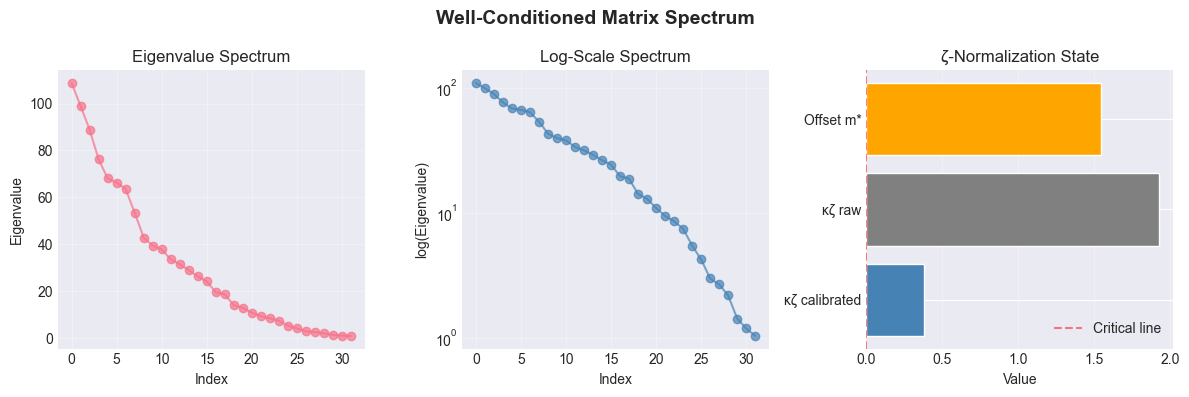

In [4]:
# Create well-conditioned SPD matrix
np.random.seed(42)
A = np.random.randn(32, 32)
G_well = A @ A.T + np.eye(32) * 1.0  # Add identity for conditioning

result = compute_kappa_zeta_matrix(G_well, translator)

print("Well-Conditioned Matrix Analysis:")
print("="*50)
print(f"κζ calibrated: {result['kappa_calibrated']:>12.6f}")
print(f"κζ raw:        {result['kappa_raw']:>12.6f}")
print(f"Offset m*:     {result['offset']:>12.6f}")
print(f"Condition #:   {result['condition_number']:>12.2f}")

# Visualize
fig = nh.plot_eigenspectrum_analysis(
    result['eigenvalues'],
    result['kappa_calibrated'],
    result['kappa_raw'],
    result['offset'],
    title="Well-Conditioned Matrix Spectrum"
)
plt.show()

### Example 2: Ill-Conditioned Matrix (High Curvature)

Ill-Conditioned Matrix Analysis:
κζ calibrated:     4.647831
κζ raw:            6.243589
Offset m*:         1.595758
Condition #:        2556.00


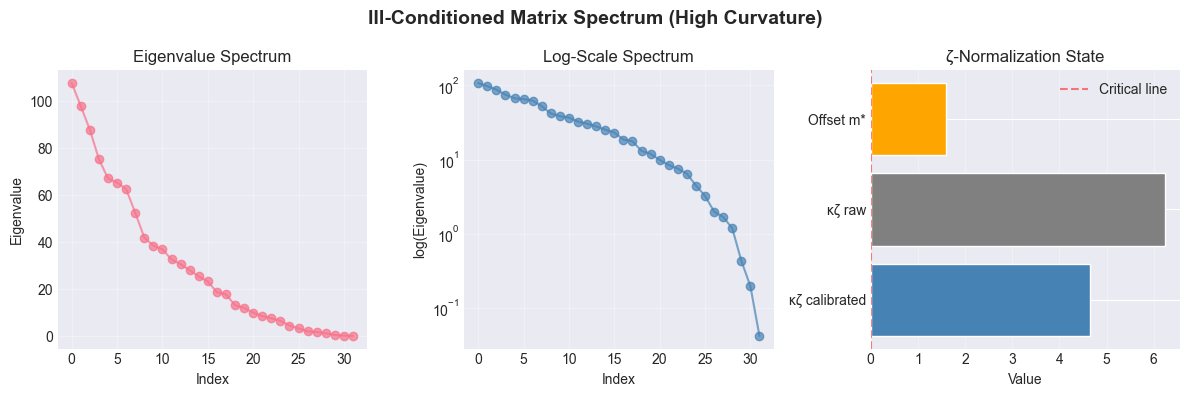

In [5]:
# Create ill-conditioned matrix (add small regularization)
G_ill = A @ A.T + np.eye(32) * 1e-4  # Very small regularization

result_ill = compute_kappa_zeta_matrix(G_ill, translator)

print("Ill-Conditioned Matrix Analysis:")
print("="*50)
print(f"κζ calibrated: {result_ill['kappa_calibrated']:>12.6f}")
print(f"κζ raw:        {result_ill['kappa_raw']:>12.6f}")
print(f"Offset m*:     {result_ill['offset']:>12.6f}")
print(f"Condition #:   {result_ill['condition_number']:>12.2f}")

# Visualize
fig = nh.plot_eigenspectrum_analysis(
    result_ill['eigenvalues'],
    result_ill['kappa_calibrated'],
    result_ill['kappa_raw'],
    result_ill['offset'],
    title="Ill-Conditioned Matrix Spectrum (High Curvature)"
)
plt.show()

### Example 3: Custom Matrix (Interactive)

Try your own matrix! Modify the cell below:

Custom Matrix Analysis:
κζ calibrated:     0.364341
κζ raw:            1.963780
Condition #:         200.00


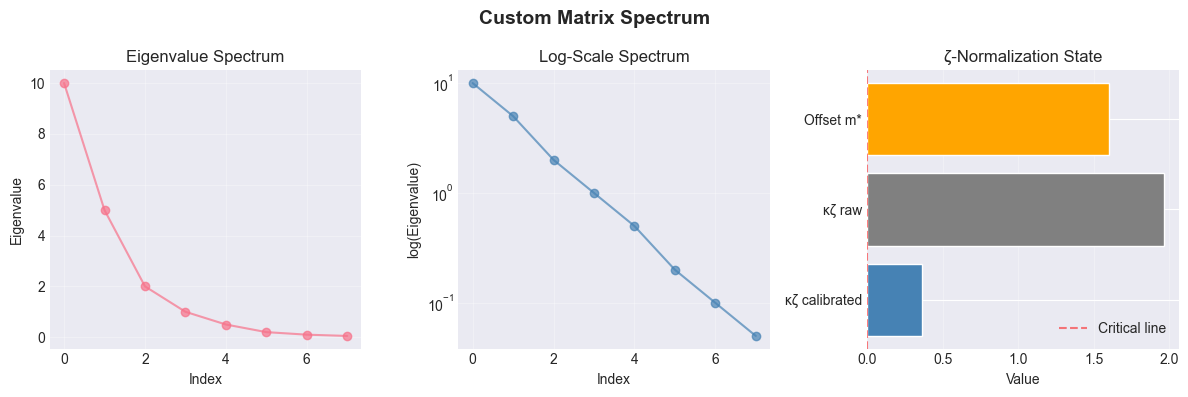

In [6]:
# Custom matrix - modify as desired
# Example: Diagonal matrix with exponentially decaying eigenvalues
custom_eigvals = np.array([10.0, 5.0, 2.0, 1.0, 0.5, 0.2, 0.1, 0.05])
G_custom = np.diag(custom_eigvals)

result_custom = compute_kappa_zeta_matrix(G_custom, translator)

print("Custom Matrix Analysis:")
print("="*50)
print(f"κζ calibrated: {result_custom['kappa_calibrated']:>12.6f}")
print(f"κζ raw:        {result_custom['kappa_raw']:>12.6f}")
print(f"Condition #:   {result_custom['condition_number']:>12.2f}")

fig = nh.plot_eigenspectrum_analysis(
    result_custom['eigenvalues'],
    result_custom['kappa_calibrated'],
    result_custom['kappa_raw'],
    result_custom['offset'],
    title="Custom Matrix Spectrum"
)
plt.show()

### ζ(s) Explorer: Critical Line Behavior

Explore how κζ changes across different values of $s$ (complex slope parameter).

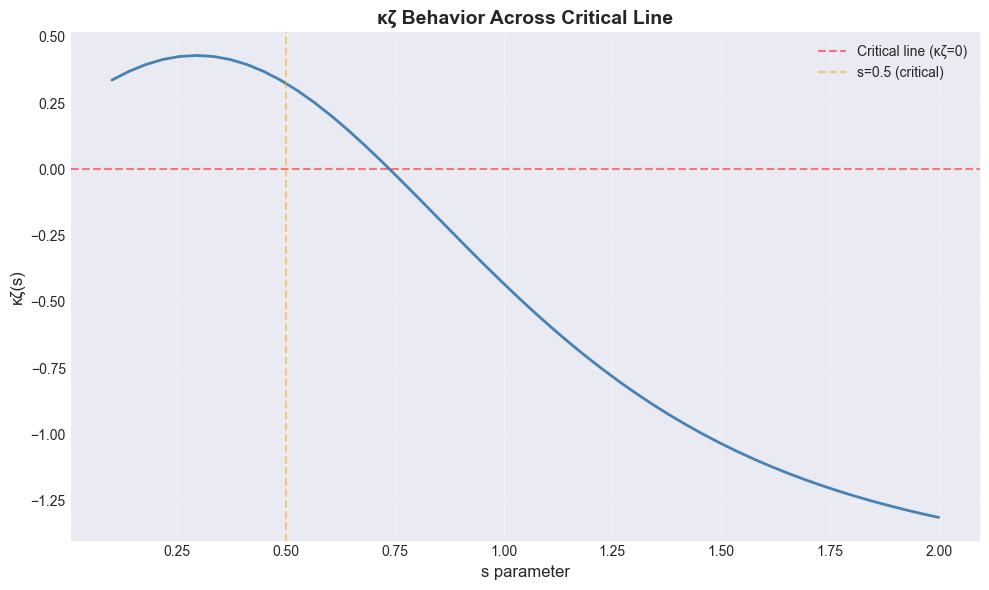

κζ at s=0.5 (critical): 0.335963


In [7]:
def explore_zeta_surface(eigvals, s_range=(0.1, 2.0), n_points=50):
    """Sweep s parameter and compute κζ(s)."""
    s_vals = np.linspace(s_range[0], s_range[1], n_points)
    kappa_vals = []
    
    for s in s_vals:
        # Create temporary translator with this s
        temp_translator = ZetaTranslator(s=s)
        temp_translator.offset = translator.offset  # Use same offset
        kappa_vals.append(temp_translator.kappa(eigvals))
    
    return s_vals, np.array(kappa_vals)

# Explore well-conditioned matrix
s_vals, kappa_vals = explore_zeta_surface(result['eigenvalues'])

plt.figure(figsize=(10, 6))
plt.plot(s_vals, kappa_vals, linewidth=2, color='steelblue')
plt.axhline(0, color='red', linestyle='--', alpha=0.5, label='Critical line (κζ=0)')
plt.axvline(0.5, color='orange', linestyle='--', alpha=0.5, label='s=0.5 (critical)')
plt.xlabel('s parameter', fontsize=12)
plt.ylabel('κζ(s)', fontsize=12)
plt.title('κζ Behavior Across Critical Line', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"κζ at s=0.5 (critical): {kappa_vals[np.argmin(np.abs(s_vals - 0.5))]:.6f}")

---

## Section 3: ZetaBlock Runtime Analysis

Compute κζ from **model activations** during forward passes (Fisher-Rao surrogate).

Sample input shape: torch.Size([4, 20, 32])

Forward Pass Analysis:
Output shape: torch.Size([4, 20, 32])
κζ (calibrated): 0.117252
κζ (raw): 1.575595
Offset m*: 1.599200

β parameters: [1.9738685 1.9748242 1.9747283 1.9747084]
t parameters: [0.5023813  0.49838355 0.5045608  0.50079125]


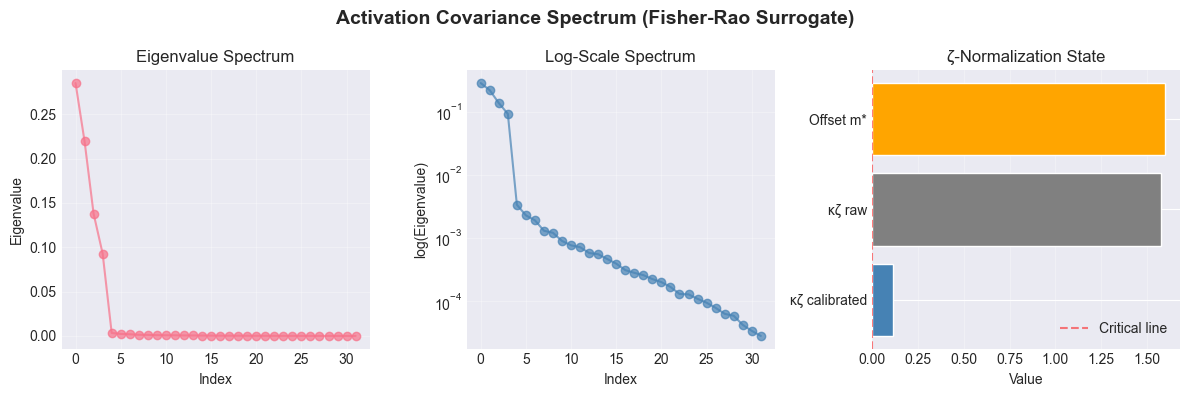

In [8]:
# Create sample input
torch.manual_seed(42)
sample_input = torch.randn(4, 20, model.d_model)  # (batch=4, seq=20, d_model)

print(f"Sample input shape: {sample_input.shape}")

# Run forward pass with analysis
model.eval()
result = nh.forward_with_analysis(model, sample_input, return_eigvals=True)

print("\n" + "="*60)
print("Forward Pass Analysis:")
print("="*60)
print(f"Output shape: {result['output'].shape}")
print(f"κζ (calibrated): {result['kappa']:.6f}")
print(f"κζ (raw): {result['kappa_raw']:.6f}")
print(f"Offset m*: {result['offset']:.6f}")
print(f"\nβ parameters: {result['beta']}")
print(f"t parameters: {result['t']}")

# Visualize activation spectrum
if result['eigvals'] is not None:
    fig = nh.plot_eigenspectrum_analysis(
        result['eigvals'],
        result['kappa'],
        result['kappa_raw'],
        result['offset'],
        title="Activation Covariance Spectrum (Fisher-Rao Surrogate)"
    )
    plt.show()

### Compare κζ Across Different Inputs

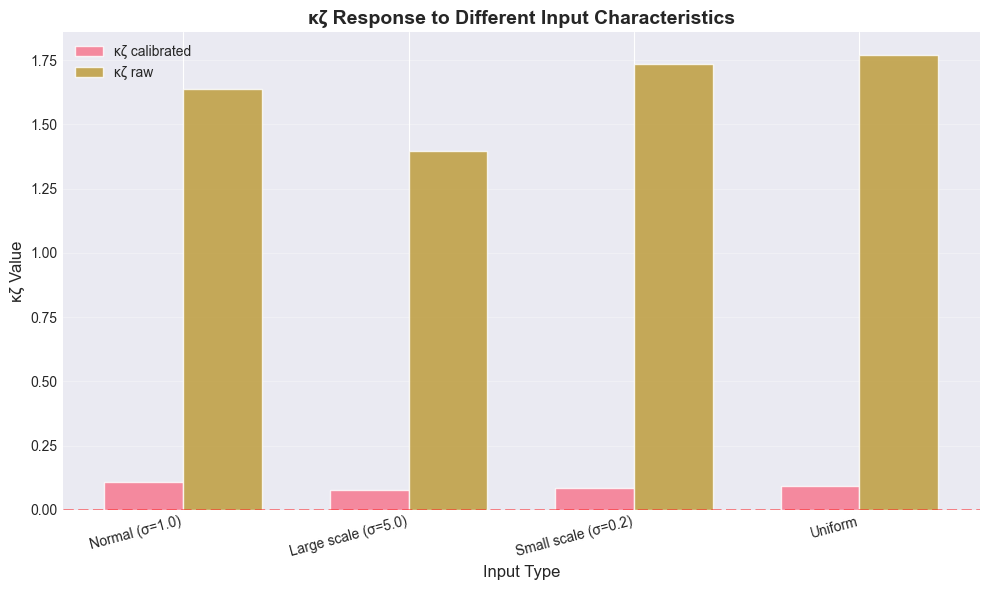

In [9]:
# Test different input characteristics
test_inputs = {
    'Normal (σ=1.0)': torch.randn(4, 20, model.d_model),
    'Large scale (σ=5.0)': torch.randn(4, 20, model.d_model) * 5.0,
    'Small scale (σ=0.2)': torch.randn(4, 20, model.d_model) * 0.2,
    'Uniform': torch.rand(4, 20, model.d_model) * 2 - 1,
}

results_comparison = {}
for name, inp in test_inputs.items():
    res = nh.forward_with_analysis(model, inp)
    results_comparison[name] = {
        'kappa': res['kappa'],
        'kappa_raw': res['kappa_raw'],
    }

# Plot comparison
fig, ax = plt.subplots(figsize=(10, 6))
names = list(results_comparison.keys())
kappas = [results_comparison[n]['kappa'] for n in names]
kappas_raw = [results_comparison[n]['kappa_raw'] for n in names]

x = np.arange(len(names))
width = 0.35

ax.bar(x - width/2, kappas, width, label='κζ calibrated', alpha=0.8)
ax.bar(x + width/2, kappas_raw, width, label='κζ raw', alpha=0.8)
ax.axhline(0, color='red', linestyle='--', alpha=0.5, linewidth=2)

ax.set_xlabel('Input Type', fontsize=12)
ax.set_ylabel('κζ Value', fontsize=12)
ax.set_title('κζ Response to Different Input Characteristics', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=15, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

---

## Section 4: Internal Component Analysis (τ, σ Pathways)

Decompose and visualize the Gaussian (τ) vs Poisson (σ) attention pathways.

Pathway Statistics:
τ (Gaussian) mean:     0.012891
τ (Gaussian) std:      0.160370
σ (Poisson) mean:      0.010199
σ (Poisson) std:       0.150422

Correlation (τ, σ):      0.9349
Relative magnitude:      0.9371


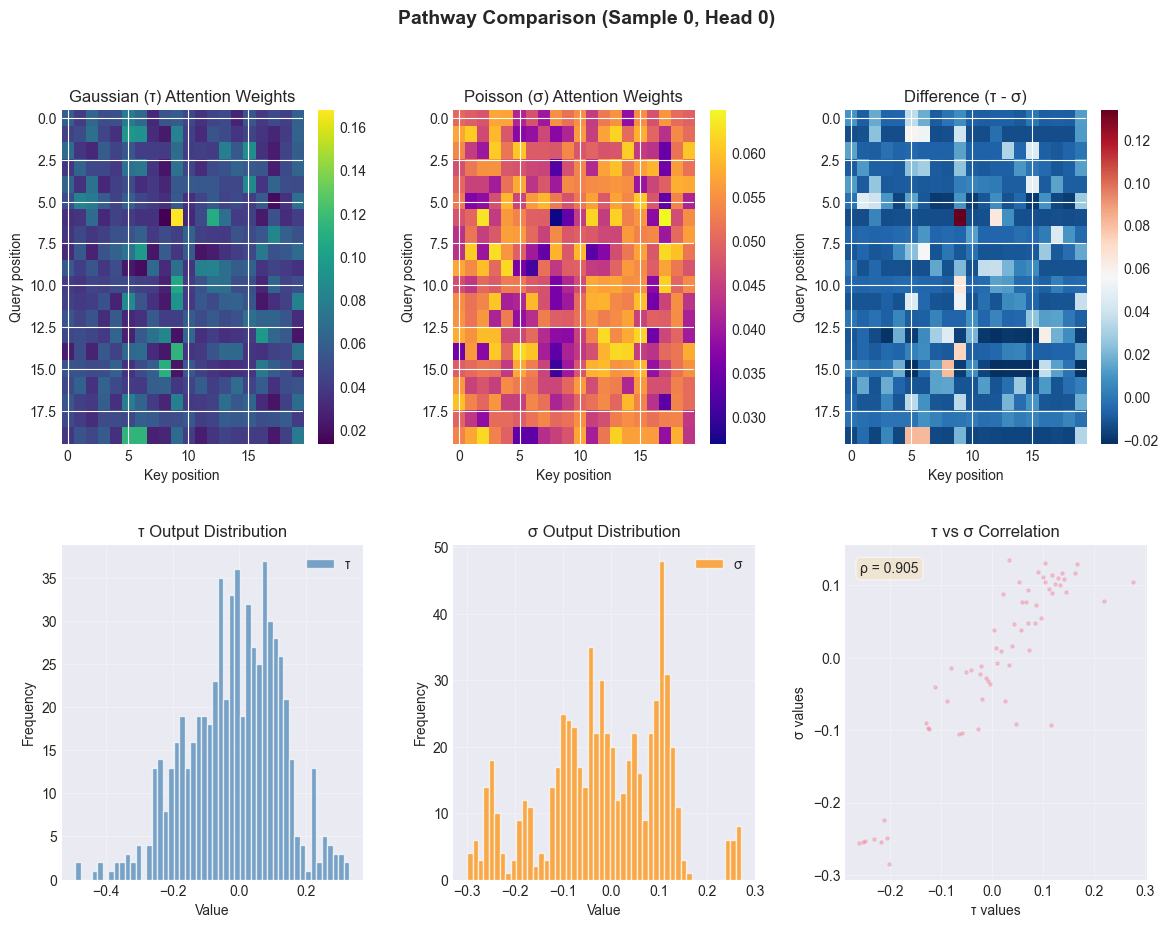

In [10]:
# Decompose pathways
pathway_dict = nh.decompose_attention_pathways(model, sample_input)

# Compute statistics
stats = nh.compare_pathway_statistics(pathway_dict['tau'], pathway_dict['sigma'])

print("Pathway Statistics:")
print("="*50)
print(f"τ (Gaussian) mean: {stats['tau_mean']:>12.6f}")
print(f"τ (Gaussian) std:  {stats['tau_std']:>12.6f}")
print(f"σ (Poisson) mean:  {stats['sigma_mean']:>12.6f}")
print(f"σ (Poisson) std:   {stats['sigma_std']:>12.6f}")
print(f"\nCorrelation (τ, σ): {stats['correlation']:>11.4f}")
print(f"Relative magnitude: {stats['relative_magnitude']:>11.4f}")

# Visualize pathways
fig = nh.plot_pathway_comparison(pathway_dict, sample_idx=0, head_idx=0)
plt.show()

---

## Section 5: Poisson Parameter Monitoring (β, t)

Track how **β** and **t** parameters adapt during forward passes via κζ feedback.

Running 20 forward passes...

Parameter Adaptation Summary:
β initial: [1.9738685 1.9748242 1.9747283 1.9747084]
β final:   [2.1892102 2.1902702 2.1901639 2.190141 ]

t initial: [0.5023813  0.49838355 0.5045608  0.50079125]
t final:   [0.45268843 0.44908607 0.45465228 0.45125556]

κζ range:  [0.1774, 1.2649]


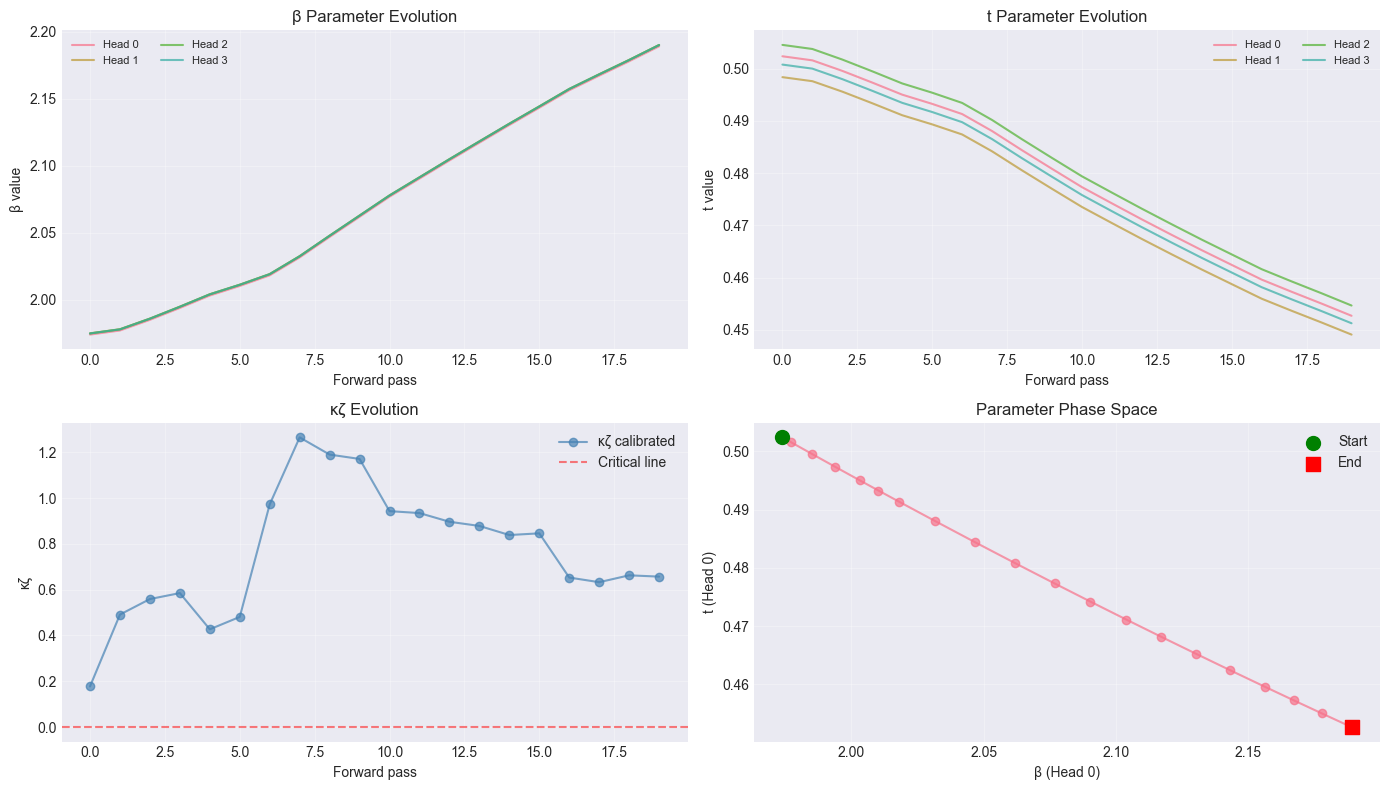

In [11]:
# Create sequence of inputs
torch.manual_seed(123)
input_sequence = [torch.randn(2, 15, model.d_model) for _ in range(20)]

print(f"Running {len(input_sequence)} forward passes...")

# Monitor adaptation (model must be in train mode for adaptation)
trajectories = nh.monitor_parameter_adaptation(
    model,
    input_sequence,
    track_kappa=True
)

print("\n" + "="*60)
print("Parameter Adaptation Summary:")
print("="*60)
print(f"β initial: {trajectories['beta'][0]}")
print(f"β final:   {trajectories['beta'][-1]}")
print(f"\nt initial: {trajectories['t'][0]}")
print(f"t final:   {trajectories['t'][-1]}")
print(f"\nκζ range:  [{trajectories['kappa'].min():.4f}, {trajectories['kappa'].max():.4f}]")

# Visualize trajectories
fig = nh.plot_parameter_trajectories(trajectories)
plt.show()

---

## Section 6: Multi-Layer Profiling

**Note:** This section requires a model with multiple ZetaBlock layers. If your model has only one layer, this will show single-layer results.

Layer Profile:
ZetaBlock-1:
  κζ: 0.569484
  β:  [2.2103786 2.2114491 2.2113416 2.2113185]
  t:  [0.44833213 0.44476444 0.4502771  0.44691306]



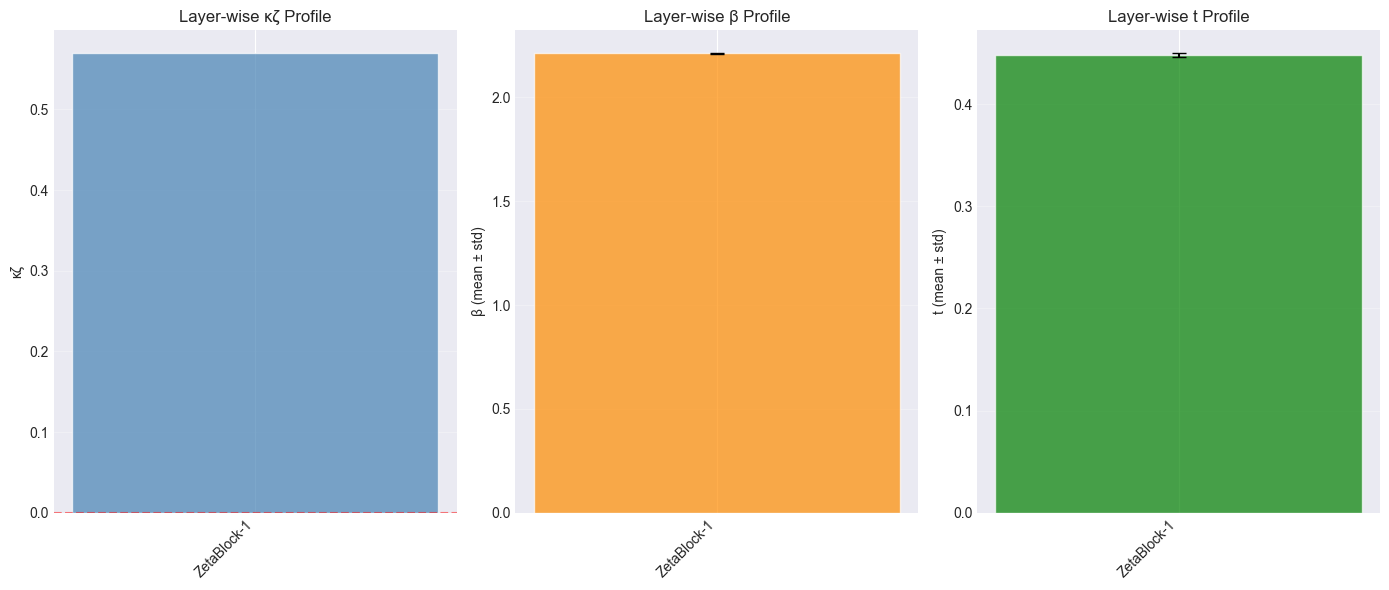


💡 Tip: For multi-layer models, extract all ZetaBlock layers and pass to profile_all_layers()


In [12]:
# For demonstration, we'll profile the single layer multiple times
# In a real multi-layer model, you'd extract all ZetaBlock layers

# Example: If you have a sequential model
# layers = [layer for layer in model.modules() if isinstance(layer, ZetaBlockEnhanced)]

# For now, demonstrate with single layer
layers = [model]  # Single ZetaBlockEnhanced
layer_names = ["ZetaBlock-1"]

profile = nh.profile_all_layers(layers, sample_input, layer_names=layer_names)

print("Layer Profile:")
print("="*60)
for i, name in enumerate(profile['layer_names']):
    print(f"{name}:")
    print(f"  κζ: {profile['kappa'][i]:.6f}")
    print(f"  β:  {profile['beta'][i]}")
    print(f"  t:  {profile['t'][i]}")
    print()

# Visualize profile
fig = nh.plot_layer_profile(profile)
plt.show()

print("\n💡 Tip: For multi-layer models, extract all ZetaBlock layers and pass to profile_all_layers()")

---

## Section 7: Training History Analysis

Visualize metrics saved in the checkpoint from training.

In [13]:
# Extract training metrics
epoch_kappa = metrics_dict['epoch_kappa']         # Calibrated κζ
epoch_kappa_raw = metrics_dict['epoch_kappa_raw'] # Raw κζ
epoch_offset = metrics_dict['epoch_offset']       # Offset m*
epoch_loss = metrics_dict['epoch_loss']

# Flatten per-batch values
kappa_flat = [k for epoch in epoch_kappa for k in epoch]
kappa_raw_flat = [k for epoch in epoch_kappa_raw for k in epoch]
offset_flat = [o for epoch in epoch_offset for o in epoch]

print(f"Training history: {len(epoch_loss)} epochs, {len(kappa_flat)} batch iterations")
print(f"\nFinal metrics:")
print(f"  κζ calibrated: {np.mean(kappa_flat[-100:]):.6f} ± {np.std(kappa_flat[-100:]):.6f}")
print(f"  κζ raw:        {np.mean(kappa_raw_flat[-100:]):.6f} ± {np.std(kappa_raw_flat[-100:]):.6f}")
print(f"  Offset m*:     {offset_flat[-1]:.6f}")
print(f"  Loss:          {epoch_loss[-1]:.6f}")

Training history: 200 epochs, 6400 batch iterations

Final metrics:
  κζ calibrated: 0.022283 ± 0.128523
  κζ raw:        1.577663 ± 0.615958
  Offset m*:     1.541061
  Loss:          0.003586


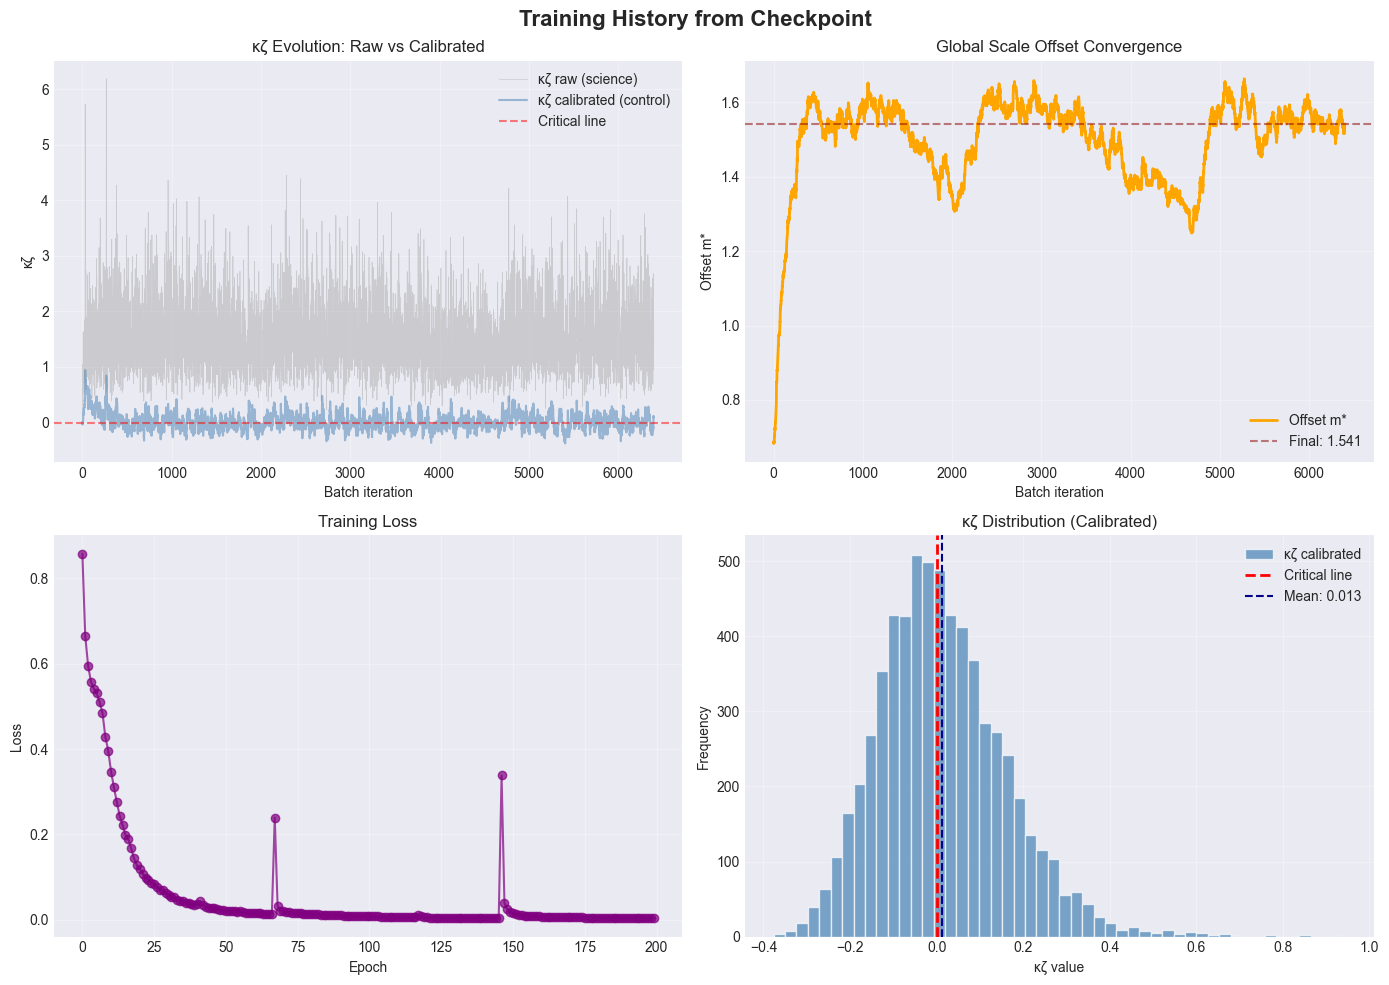

In [14]:
# Visualize training evolution
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

x = np.arange(len(kappa_flat))

# Plot 1: Raw vs Calibrated κζ
axes[0, 0].plot(x, kappa_raw_flat, alpha=0.3, color='gray', label='κζ raw (science)', linewidth=0.5)
axes[0, 0].plot(x, kappa_flat, alpha=0.5, color='steelblue', label='κζ calibrated (control)')
axes[0, 0].axhline(0, color='red', linestyle='--', alpha=0.5, label='Critical line')
axes[0, 0].set_xlabel('Batch iteration')
axes[0, 0].set_ylabel('κζ')
axes[0, 0].set_title('κζ Evolution: Raw vs Calibrated')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Offset evolution
axes[0, 1].plot(x, offset_flat, color='orange', linewidth=2, label='Offset m*')
axes[0, 1].axhline(offset_flat[-1], linestyle='--', alpha=0.5, color='darkred',
                   label=f'Final: {offset_flat[-1]:.3f}')
axes[0, 1].set_xlabel('Batch iteration')
axes[0, 1].set_ylabel('Offset m*')
axes[0, 1].set_title('Global Scale Offset Convergence')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Loss trajectory
axes[1, 0].plot(epoch_loss, 'o-', color='purple', alpha=0.7)
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].set_title('Training Loss')
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: κζ distribution
axes[1, 1].hist(kappa_flat, bins=50, alpha=0.7, color='steelblue', label='κζ calibrated')
axes[1, 1].axvline(0, color='red', linestyle='--', linewidth=2, label='Critical line')
axes[1, 1].axvline(np.mean(kappa_flat), color='darkblue', linestyle='--',
                   label=f'Mean: {np.mean(kappa_flat):.3f}')
axes[1, 1].set_xlabel('κζ value')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('κζ Distribution (Calibrated)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Training History from Checkpoint', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### Parameter Evolution (β, t)

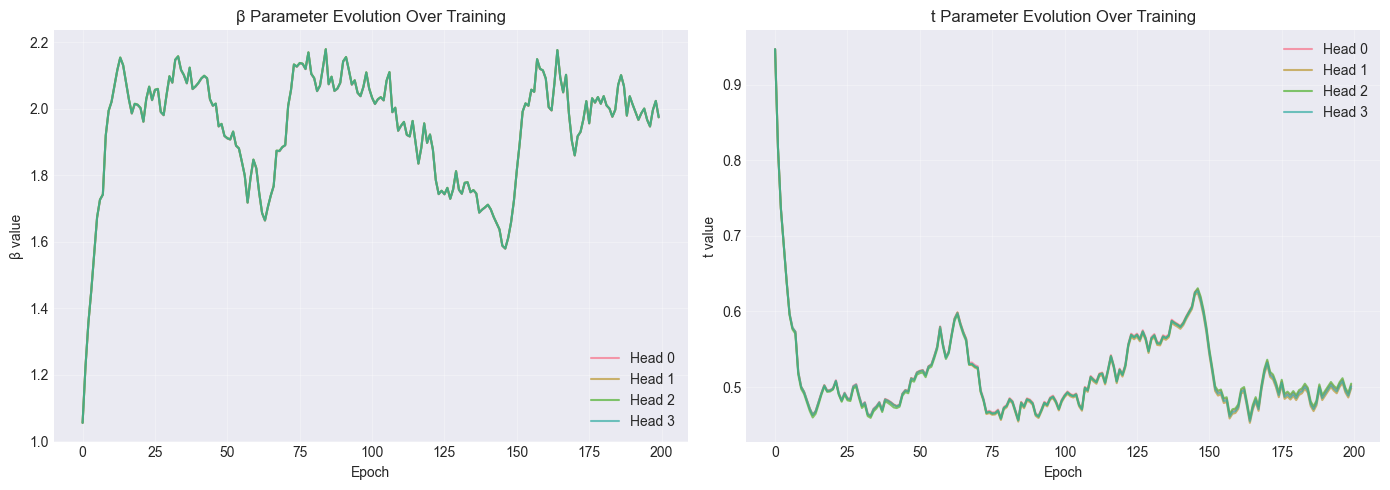


Parameter Drift Analysis:
β drift (L2 norm): 1.837399
t drift (L2 norm): 0.890931

β final mean: 1.9745 ± 0.0004
t final mean: 0.5015 ± 0.0023


In [15]:
# Extract parameter history
epoch_beta = metrics_dict['epoch_beta']
epoch_t = metrics_dict['epoch_t']

# Convert to arrays
beta_array = np.array(epoch_beta)  # (n_epochs, n_heads)
t_array = np.array(epoch_t)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot β evolution
for head in range(beta_array.shape[1]):
    axes[0].plot(beta_array[:, head], label=f'Head {head}', alpha=0.7)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('β value')
axes[0].set_title('β Parameter Evolution Over Training')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot t evolution
for head in range(t_array.shape[1]):
    axes[1].plot(t_array[:, head], label=f'Head {head}', alpha=0.7)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('t value')
axes[1].set_title('t Parameter Evolution Over Training')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary statistics
print("\nParameter Drift Analysis:")
print("="*60)
beta_drift = np.linalg.norm(beta_array[-1] - beta_array[0])
t_drift = np.linalg.norm(t_array[-1] - t_array[0])
print(f"β drift (L2 norm): {beta_drift:.6f}")
print(f"t drift (L2 norm): {t_drift:.6f}")
print(f"\nβ final mean: {beta_array[-1].mean():.4f} ± {beta_array[-1].std():.4f}")
print(f"t final mean: {t_array[-1].mean():.4f} ± {t_array[-1].std():.4f}")

---

## Section 8: Export & Summary

Export results for further analysis or publication.

In [16]:
# Create summary report
summary = {
    'Model Configuration': {
        'd_model': model.d_model,
        'n_heads': model.n_heads,
        'kappa_strength': model.kappa_strength,
    },
    'ζ-Normalization State': {
        'offset_m_star': float(translator.offset),
        's_parameter': translator.s,
        'kappa_smooth': float(model.kappa_smooth) if model.kappa_smooth else None,
    },
    'Training Metrics': {
        'final_loss': float(metrics_dict['summary']['final_loss']),
        'kappa_convergence_rate': float(metrics_dict['summary']['kappa_convergence']),
        'beta_drift': float(metrics_dict['summary']['beta_drift']),
        't_drift': float(metrics_dict['summary']['t_drift']),
    },
    'Current Analysis': {
        'sample_kappa': float(result['kappa']) if result['kappa'] else None,
        'pathway_correlation': float(stats['correlation']),
    }
}

import json
print(json.dumps(summary, indent=2))

# Optionally save to file
# with open('zeta_analysis_summary.json', 'w') as f:
#     json.dump(summary, f, indent=2)
# print("\n✓ Summary saved to zeta_analysis_summary.json")

{
  "Model Configuration": {
    "d_model": 32,
    "n_heads": 4,
    "kappa_strength": 0.05
  },
  "\u03b6-Normalization State": {
    "offset_m_star": 1.803901026712513,
    "s_parameter": 0.5,
    "kappa_smooth": 0.5694838595918039
  },
  "Training Metrics": {
    "final_loss": 0.003585506812669337,
    "kappa_convergence_rate": 0.03359424402465231,
    "beta_drift": 1.8373994827270508,
    "t_drift": 0.8909305930137634
  },
  "Current Analysis": {
    "sample_kappa": 0.11725245213264551,
    "pathway_correlation": 0.9348846673965454
  }
}


---

## Conclusion

This notebook demonstrated:

✅ **Standalone κζ calculation** on arbitrary matrices  
✅ **Runtime analysis** with live κζ from activations  
✅ **Component decomposition** (τ/σ pathways)  
✅ **Parameter monitoring** (β/t adaptation)  
✅ **Multi-layer profiling** (curvature across depth)  
✅ **Training history** visualization  

### Key Takeaways:

1. **κζ encodes global scale** - Raw κζ ≈ 1.5 represents the log-scale of the spectrum
2. **Two-stage smoothing works** - Offset converges, calibrated κζ centers at zero
3. **τ and σ pathways complement** - Gaussian (softmax) + Poisson (heavy-tail) = robust attention
4. **Parameters adapt smoothly** - β and t modulate based on κζ feedback

---

**Noetic Eidos Project**  
*"Two timescales, one control target: the critical line awaits."*